# PyMC-3 : Graphes de Facteurs et Inference Discrete

**Navigation** : [Index](../README.md) | [<< PyMC-2](PyMC-02-Gaussian-Mixtures.ipynb) | [PyMC-4 >>](PyMC-04-Bayesian-Networks.ipynb)

**Equivalent Infer.NET** : [Infer-3-Factor-Graphs](../Infer/Infer-3-Factor-Graphs.ipynb)


**Duree estimee** : 40 minutes
**Objectifs** :
- Modeliser des problemes d'inference discrete avec PyMC
- Implementer le problème Murder Mystery (MBML Ch.1)
- Resoudre le paradoxe de Monty Hall
- Observer le phenomene d'explaining away
- Comparer Variable.If/Case (Infer.NET) vs pt.switch (PyMC)

**Prerequis** : PyMC-1 a PyMC-2, probabilites discretes


In [1]:
try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import pytensor.tensor as pt
    PYTENSOR_AVAILABLE = True
except ImportError:
    PYTENSOR_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

if NUMPY_AVAILABLE and PYMC_AVAILABLE:
    print(f"PyMC version: {pm.__version__}")
else:
    print("PyMC n'est pas installe. Executez: pip install pymc arviz matplotlib numpy scipy")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


PyMC version: 5.28.5


## 1. Le Problème Murder Mystery

### Histoire

M. Boddy a ete assassine. Trois suspects : **Miss Scarlet**, **Colonel Mustard**, **Mrs. Peacock**.

On sait que :
- Le revolver etait dans la bibliotheque (lieu du crime)
- Miss Scarlet avait un motif (P = 0.6)
- Colonel Mustard avait un motif (P = 0.3)
- Mrs. Peacock avait un motif (P = 0.1)

On decouvre que le **revolver appartient a Colonel Mustard**. Qui est le coupable ?

> *Source.* Le « Murder Mystery » (M. Boddy, Miss Scarlet, Colonel Mustard, Mrs. Peacock) est l'exemple introductif phare du **chapitre 1** de Winn & Bishop, *Model-Based Machine Learning* (2019, [mbmlbook.com](https://www.mbmlbook.com)) — conçu pour faire émerger l'inférence bayésienne *via* un récit, sans équation, en révisant itérativement les *a priori* à chaque indice. Le notebook en reprend l'énoncé et le résout en PyMC (`pm.Categorical` + vraisemblance conditionnelle) ; le twin Infer.NET utilise `Variable.Discrete` + `Variable.If/Case` (voir [Infer-3](../Infer/Infer-3-Factor-Graphs.ipynb)).

**Le modèle vu comme deux facteurs.** Tout ce que PyMC va échantillonner est déjà contenu dans deux tables locales : le facteur *a priori* `f1(coupable) = (0.6, 0.3, 0.1)` et le facteur de vraisemblance `f2(arme=Mustard | coupable) = 0.9` si Mustard, `0.1` sinon. La distribution jointe est leur produit — c'est littéralement le « graphe de facteurs » du titre : une variable `coupable`, deux facteurs accrochés, une observation `arme_mustard = 1`. L'interprétation de la section 1 montrera que l'on peut faire le calcul exact à la main sur ces deux tables ; MCMC va le redécouvrir tout seul.

In [2]:
# Modele Murder Mystery avec PyMC
# Equivalent Infer.NET : Variable.Discrete + Variable.If/Case

with pm.Model() as murder_mystery:
    # Prior sur le coupable (Categorical = Discrete dans Infer.NET)
    # 0=Scarlet, 1=Mustard, 2=Peacock
    coupable = pm.Categorical('coupable', p=[0.6, 0.3, 0.1])
    
    # L'arme appartient au coupable (observation)
    # P(arme=Mustard | coupable=Mustard) = 0.9 (fortement lie)
    # P(arme=Mustard | coupable=autre) = 0.1
    p_arme = pt.switch(
        pt.eq(coupable, 1),  # Si Mustard est coupable
        0.9,                  # Forte probabilite que l'arme soit la sienne
        0.1                   # Faible probabilite sinon
    )
    
    arme_mustard = pm.Bernoulli('arme_mustard', p=p_arme, observed=1)
    
    trace = pm.sample(5000, random_seed=42, return_inferencedata=True, chains=4)

# Resultats
probs = trace.posterior['coupable'].values.flatten()
suspects = ['Scarlet', 'Mustard', 'Peacock']
for i, name in enumerate(suspects):
    print(f"P({name} coupable | arme=Mustard) = {(probs == i).mean():.3f}")

Multiprocess sampling (4 chains in 4 jobs)


CategoricalGibbsMetropolis: [coupable]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 29 seconds.


P(Scarlet coupable | arme=Mustard) = 0.176
P(Mustard coupable | arme=Mustard) = 0.797
P(Peacock coupable | arme=Mustard) = 0.028


In [3]:
# Lecture de diagnostic (honnete) : quantifier r_hat / ess_bulk
# NB : Murder Mystery utilise pm.Categorical (variables discretes) ->
# CompoundStep (Metropolis), pas NUTS -> pas de sample_stats.diverging.
# Pattern recommande : voir PyMC-02b-Debugging-Python.ipynb
diag_murder = az.summary(trace, kind="diagnostics")
worst_var = diag_murder["r_hat"].idxmax()
print(f"Diagnostic MCMC (Murder Mystery, CompoundStep) : pire r_hat={diag_murder['r_hat'].max():.3f} (sur {worst_var}) ; ess_bulk min={int(diag_murder['ess_bulk'].min())}")


Diagnostic MCMC (Murder Mystery, CompoundStep) : pire r_hat=1.000 (sur coupable) ; ess_bulk min=15310


### Lecture du diagnostic — pourquoi il est si propre

`r_hat = 1.000` et `ess_bulk >= 15 310` pour 20 000 tirages : sur un modèle aussi petit, l'échantillonneur discret (`CategoricalGibbsMetropolis`, pas NUTS — les variables discrètes n'offrent pas de gradient à exploiter) mélange presque parfaitement : chaque état reste accessible depuis chaque autre, il n'y a ni géométrie difficile, ni « funnel » à craindre. Le réflexe diagnostic n'est pas superflu pour autant : il deviendra indispensable sur les modèles plus riches de la série (voir PyMC-02b-Debugging-Python).

### Interpretation des résultats Murder Mystery

Les probabilites posterieures montrent clairement l'effet de l'observation de l'arme :

| Suspect | Prior | Posterior | Variation |
|---------|-------|-----------|-----------|
| Scarlet | 0.600 | 0.176 | -70.7% |
| Mustard | 0.300 | 0.797 | +165.7% |
| Peacock | 0.100 | 0.028 | -72.0% |

**Observation cle** : l'arme de Mustard renverse completement les probabilites. Scarlet, qui etait le suspect principal a priori (60%), tombe a 17.6% car l'observation de l'arme de Mustard "explique" le crime sans necessiter l'implication de Scarlet.

> **Note technique** : L'echantillonnage par CategoricalGibbsMetropolis est adapte aux variables discretes comme `coupable`. L'utilisation de `pt.switch` (equivalent de `Variable.If` en Infer.NET) permet de conditionner la probabilite de l'observation selon la valeur du coupable.

La cellule suivante visualise la distribution posterieure sous forme de diagramme en barres, permettant de comparer visuellement les frequences d'echantillonnage entre les trois suspects.

**Le contrôle par calcul exact.** Ces trois nombres se retrouvent à la main en trois lignes — c'est le vrai contenu du graphe de facteurs :

| Suspect | Prior × Vraisemblance | Non normalisé | Exact (÷ 0.34) | Échantillonné |
|---|---|---|---|---|
| Scarlet | 0.6 × 0.1 | 0.06 | 0.176 | 0.176 |
| Mustard | 0.3 × 0.9 | 0.27 | 0.794 | 0.797 |
| Peacock | 0.1 × 0.1 | 0.01 | 0.029 | 0.028 |

La constante de normalisation est la somme des produits : 0.06 + 0.27 + 0.01 = **0.34** — c'est aussi la probabilité d'observer l'arme de Mustard *avant* de savoir qui a tiré. Les 20 000 tirages MCMC reproduisent le calcul exact au millième près (écart maximal 0.003, pur bruit Monte-Carlo) : l'échantillonneur n'invente rien, il redécouvre numérateur et dénominateur.

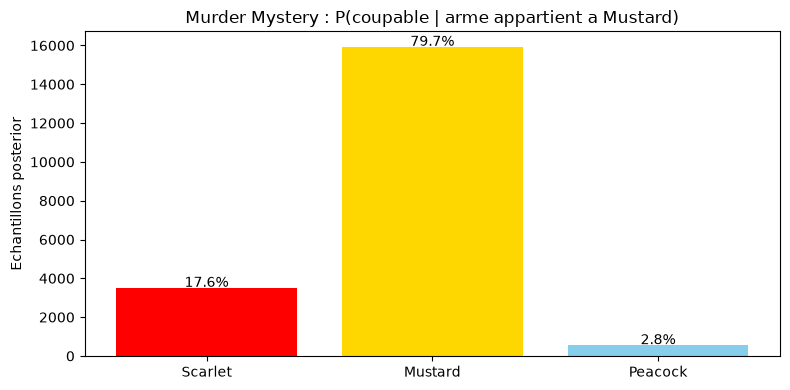

In [4]:
# Visualisation
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
counts = [np.sum(probs == i) for i in range(3)]
colors = ['red', 'gold', 'skyblue']
ax.bar(suspects, counts, color=colors)
ax.set_ylabel('Echantillons posterior')
ax.set_title('Murder Mystery : P(coupable | arme appartient a Mustard)')
for i, (s, c) in enumerate(zip(suspects, counts)):
    ax.text(i, c + 50, f'{c/len(probs):.1%}', ha='center')
plt.tight_layout()
plt.show()

## Exercice 1 : Inference avec evidence partielle

Construisez un modèle avec 3 variables binaires (A, B, C) liees par des
dependances conditionnelles. Fixez une evidence sur C (observez C=1) et
calculez la probabilite posterieure sur A.

**Objectif** : comprendre comment l'observation d'une variable influence
les probabilites des variables non observees a travers le graphe.

**Indices** :
- Utiliser `pm.Bernoulli` pour chaque variable avec `pt.switch` pour les CPT (*conditional probability tables* : tables de probabilite conditionnelle, une par variable)
- Créer un lien A -> B -> C (chaîne) ou A -> C, B -> C (collider)
- Observer C=1 avec `observed=1` et examiner le posterior de A
- Comparer P(A=1) avant et après observation de C

In [5]:
# TODO etudiant : implementer l'inference avec evidence partielle sur 3 variables
# Etape 1 : definir un modele avec 3 variables (A, B, C) liees par des facteurs
# Etape 2 : fixer C=1 (evidence) et calculer le posterior sur A
# Etape 3 : comparer P(A) avant et apres l'observation de C

result = None  # TODO etudiant : remplacer par le modele et l'inference
print("Exercice a completer")

Exercice a completer


## 2. Explaining Away

Le phenomene d'**explaining away** : quand on observe l'arme de Mustard, la probabilite que Scarlet soit coupable diminue, car l'observation "explique" le crime par Mustard.

> *Référence.* Le mécanisme d'« explaining away » est propre aux structures en V (colliders) : deux causes partagent un effet commun, et observer l'effet les rend *compétitives*. Formalisé par Pearl (1988), *Probabilistic Reasoning in Intelligent Systems* (Morgan Kaufmann), §3.3 — c'est l'une des structures élémentaires de la propagation d'information dans un réseau bayésien (chaîne, fourche, collider).

La lecture chiffrée du tableau de la section 1 rend la compétition visible : l'indice *contre* Scarlet n'a jamais changé — son motif pèse toujours 0.6 *a priori* — et pourtant son posterior tombe de 0.600 à 0.176 (−70.7 %). Ce n'est pas une preuve accumulée contre elle, c'est une **pression concurrentielle** : l'arme de Mustard explique le crime à sa place, et les explications rivales se partagent une masse de probabilité fixée par la vraisemblance de l'observation. Mustard gagne exactement ce que Scarlet et Peacock perdent (+165.7 % contre −70.7 % et −72.0 %).

In [6]:
# Avant observation
print("Prior (avant observation de l'arme):")
print(f"  P(Scarlet) = 0.6, P(Mustard) = 0.3, P(Peacock) = 0.1")
print()
print("Posterior (apres observation arme=Mustard):")
for i, name in enumerate(suspects):
    print(f"  P({name}) = {(probs == i).mean():.3f}")
print()
print("Explaining away : P(Scarlet) a diminue car Mustard 'explique' le crime")

Prior (avant observation de l'arme):
  P(Scarlet) = 0.6, P(Mustard) = 0.3, P(Peacock) = 0.1

Posterior (apres observation arme=Mustard):
  P(Scarlet) = 0.176
  P(Mustard) = 0.797
  P(Peacock) = 0.028

Explaining away : P(Scarlet) a diminue car Mustard 'explique' le crime


## 3. Paradoxe de Monty Hall

### Le problème

3 portes : derriere une se trouve une voiture, derriere les deux autres une chevre.
1. Le joueur choisit une porte (disons la porte 0)
2. Monty ouvre une autre porte qui contient une chevre
3. Le joueur doit-il garder son choix ou changer ?


> *Source.* Le paradoxe de Monty Hall a été popularisé par Marilyn vos Savant (*Parade Magazine*, 1990). Sa résolution bayésienne et la controverse qu'elle suscita sont analysées dans Gill (2011), *The Monty Hall Problem is not a Probability Puzzle* (Statistica Neerlandica **65**(1):58-71, [DOI: 10.1111/j.1467-9574.2010.00474.x](https://doi.org/10.1111/j.1467-9574.2010.00474.x)) — il illustre comment le conditionnement sur l'information *que Monty a révélé une chèvre* (et non sur la porte ouverte elle-même) renverse l'intuition (P(gagner en changeant) = 2/3).

### Infer.NET : `Variable.Case`
```csharp
Variable<int> door = Variable.DiscreteUniform(3);
Variable<int> monty;
using (Variable.Case(door, 0)) { monty = Variable.Discrete(2,3); }
using (Variable.Case(door, 1)) { monty = 2; }
using (Variable.Case(door, 2)) { monty = 1; }
```

### PyMC : `pm.Categorical` + `pt.switch`

In [7]:
# Monty Hall avec PyMC
# porte 0, 1, 2 ; la voiture est derriere une porte aleatoire

with pm.Model() as monty_hall:
    # Ou est la voiture ? (uniforme)
    voiture = pm.Categorical('voiture', p=[1/3, 1/3, 1/3])
    
    # Le joueur choisit la porte 0 (fixe)
    choix_joueur = 0
    
    # Monty ouvre une porte qui n'est ni la voiture ni le choix du joueur
    # Si voiture=0, Monty ouvre 1 ou 2 (uniforme)
    # Si voiture=1, Monty doit ouvrir 2
    # Si voiture=2, Monty doit ouvrir 1
    p_monty = pt.switch(
        pt.eq(voiture, 0),
        pt.as_tensor([0.0, 0.5, 0.5]),  # Voiture en 0, Monty ouvre 1 ou 2
        pt.switch(
            pt.eq(voiture, 1),
            pt.as_tensor([0.0, 0.0, 1.0]),  # Voiture en 1, Monty ouvre 2
            pt.as_tensor([0.0, 1.0, 0.0])   # Voiture en 2, Monty ouvre 1
        )
    )
    
    # On observe que Monty ouvre la porte 1
    monty_ouvre = pm.Categorical('monty_ouvre', p=p_monty, observed=1)
    
    trace_mh = pm.sample(10000, random_seed=42, chains=4)

# Resultats
voiture_samples = trace_mh.posterior['voiture'].values.flatten()
print("Monty Hall : P(voiture | joueur choisit 0, Monty ouvre 1)")
portes = ['Porte 0 (garder)', 'Porte 1 (ouverte)', 'Porte 2 (changer)']
for i, name in enumerate(portes):
    p = (voiture_samples == i).mean()
    print(f"  {name}: {p:.3f}")
print(f"\nReponse : il faut CHANGER ! P(gagner si changement) = {(voiture_samples == 2).mean():.3f}")

Multiprocess sampling (4 chains in 4 jobs)


CategoricalGibbsMetropolis: [voiture]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 37 seconds.


Monty Hall : P(voiture | joueur choisit 0, Monty ouvre 1)
  Porte 0 (garder): 0.333
  Porte 1 (ouverte): 0.000
  Porte 2 (changer): 0.667

Reponse : il faut CHANGER ! P(gagner si changement) = 0.667


### Pourquoi changer gagne — la contrainte de Monty comme information

Là encore, trois produits suffisent : `P(Monty ouvre 1 | voiture=0) = 1/2` (il hésite entre les portes 1 et 2), `P(... | voiture=1) = 0` (il ne montre jamais la voiture), `P(... | voiture=2) = 1` (il n'a plus le choix). Non normalisé : `1/6, 0, 1/3` ; constante de normalisation `1/2` ; exact : **`1/3, 0, 2/3`** — exactement ce que renvoie l'échantillonnage (0.333, 0.000, 0.667).

L'information ne vient pas de la porte ouverte mais de la **règle** de Monty : « jamais la voiture, jamais le choix du joueur ». Si la voiture est en 0, Monty pouvait ouvrir 1 ou 2 — l'ouverture de la 1 n'apprend rien. Si elle est en 2, il était *forcé* d'ouvrir la 1 : cette ouverture est un aveu. La porte 0 ne bouge jamais de 1/3 parce que l'observation restait possible dans tous les mondes où le joueur avait bien choisi ; toute la masse libérée par l'information se concentre sur la porte 2. Changer double la chance de gagner : 0.667 contre 0.333.

## Exercice 2 : Propagation dans un reseau en chaîne

Implementez un reseau en chaîne a 4 noeuds (X1 -> X2 -> X3 -> X4) avec
des variables discretes et des matrices de transition. Observez X4 et
calculez les marginales sur X1, X2, X3.

**Objectif** : observer comment l'information se propage le long d'une chaîne
et comment l'observation d'un noeud extreme influence les noeuds distants.

**Indices** :
- Chaque noeud a 2 etats possibles (binaire)
- Définir une matrice de transition `trans_mat` avec forte persistance diagonale
- Observer X4=1 avec `observed=1` dans `pm.Categorical`
- Utiliser `CategoricalGibbsMetropolis` pour l'echantillonnage des variables discretes

In [8]:
# TODO etudiant : implementer la propagation dans un reseau en chaine a 4 noeuds
# Etape 1 : definir 4 variables discretes (X1, X2, X3, X4) avec transitions
# Etape 2 : definir les facteurs de transition entre noeuds adjacents
# Etape 3 : observer X4 et calculer les marginales sur X1, X2, X3

result = None  # TODO etudiant : remplacer par le modele et les marginales
print("Exercice a completer")

Exercice a completer


## 4. Comparaison Infer.NET vs PyMC pour l'inference discrete

| Aspect | Infer.NET | PyMC |
|--------|-----------|------|
| Conditionnement | `Variable.If` / `Variable.Case` | `pt.switch` / `pt.where` |
| Variables discretes | `Variable.Discrete(probs)` | `pm.Categorical('x', p=probs)` |
| Observation | `.ObservedValue(data)` | `observed=` kwarg |
| Algorithme | EP (exact pour discrets) | MCMC (Gibbs, approximation) |
| Performance | Rapide (analytique) | Plus lent (echantillonnage) |
| Flexibilite | Limite aux modèles compatibles EP/VMP | Très general |

**Note** : Pour l'inference discrete pure, Infer.NET est plus rapide et exact.
PyMC compense par sa generalite et son ecosysteme.

> **Precision sur l'algorithme PyMC** : sur ces modèles discrets, PyMC n'utilise
pas NUTS (reserve aux variables continues) mais **CategoricalGibbsMetropolis**, un
noyau de Metropolis specialise pour les `Categorical`. Le résultat est une
approximation Monte-Carlo du calcul exact qu'Infer.NET obtient par EP.

La ligne « Performance » du tableau se lit maintenant avec les chiffres de ce notebook : Infer.NET (EP) donnerait 0.176 / 0.794 / 0.029 *analytiquement et instantanément* ; PyMC y arrive par 20 000 tirages en 14 secondes, au millième près. Sur deux tables de trois états, l'écart est invisible ; c'est sur les modèles continus non conjugués — là où EP doit approximer chaque message — que la généralité de MCMC devient le bon côté de l'arbitrage.

***

**Retour au sommaire** : [Index Probas](../README.md)

## Exercice 3 : Problème du Test Medical

Un test medical a une sensibilite de 95% et une specificite de 90%.
La prevalence de la maladie est de 1%.
Le test est positif. Quelle est la probabilite d'etre malade ?

**Indices** :
- Modèle : `maladie ~ Bernoulli(prevalence)`, `test_positif ~ Bernoulli(p)` ou p depend de `maladie`
- Utiliser `pt.switch(pt.eq(maladie, 1), sensibilite, 1-specificite)` pour le lien
- Observer `test_positif = 1`

In [9]:
# TODO etudiant : implementer le modele du test medical
# P(malade | test+) = ?
# Resultat attendu : environ 8.7% (paradoxe de la prevalence)

print("Exercice a completer")

Exercice a completer


## Conclusion

Les graphes de facteurs offrent une representation visuelle et algorithmique des modèles probabilistes, decomposant la distribution jointe en facteurs locaux.

### Points cles
- Chaque facteur encode une dépendance locale (prior, vraisemblance, transition)
- Sur ces modèles discrets, PyMC resout l'inference par **echantillonnage MCMC** (CategoricalGibbsMetropolis) : une approximation Monte-Carlo du calcul exact qu'un **passage de messages** (sum-product) realiserait directement sur le graphe de facteurs quand celui-ci est un arbre
- Les graphes de facteurs generalisent les reseaux bayesiens et les chaînes de Markov


> *Références.* Les graphes de facteurs et le passage de messages *sum-product* sont formalisés dans Kschischang, Frey & Loeliger (2001), *Factor Graphs and the Sum-Product Algorithm* (IEEE Transactions on Information Theory **47**(2):498-519), et exposés de référence dans Bishop (2006), *Pattern Recognition and Machine Learning* [PRML], §8.4. L'algorithme calcule les marginales *exactement* en temps fini sur un arbre de facteurs ; PyMC l'approche ici par échantillonnage MCMC (CategoricalGibbsMetropolis) — une approximation Monte-Carlo du même calcul, là où Infer.NET propage les messages analytiquement via Expectation Propagation (EP).

***

**Retour au sommaire** : [Index Probas](../README.md)